# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/boddulavinaykumar6-stack/Flyrank-ML-Internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

For this task, I compare three supervised classification models.

- Logistic Regression is used as a simple and interpretable baseline.
- Decision Tree can learn nonlinear decision rules and is easy to interpret.
- Random Forest is an ensemble of decision trees that generally provides better predictive performance while reducing overfitting.

The target variable is `trend_direction`, which contains five classes (`down`, `stable`, `up`, `new`, and `flat`). Following the FlyRank data guidance, `trend_direction` is used only as the prediction target, while `trend_pct` is excluded from the feature set because it directly determines the target and would introduce data leakage.

All models are trained using the same grouped train/test split and evaluated with the same metrics to enable a fair comparison.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import numpy as np
import pandas as pd

df = pd.read_csv('content_refresh_anonymized.csv')

RANDOM_STATE = 30

print(f"Random seed: {RANDOM_STATE}")

print("Target distribution:")
display(df["trend_direction"].value_counts())

Random seed: 30
Target distribution:


,count
trend_direction,
down,16262
stable,5962
up,4388
new,2236
flat,1152


For model evaluation, I use a grouped train/test split based on `client_id` instead of a random row-level split.

Grouping by client prevents pages from the same client appearing in both the training and testing sets, reducing the risk of overly optimistic performance estimates due to shared client-specific characteristics.

To avoid data leakage, I exclude:

- `content_id` and `client_id` (identifiers)
- `trend_direction` (target)
- `trend_pct` (used to derive the target)

Missing values are handled separately for numeric and categorical features. Numeric features are imputed with the median, while categorical features are imputed with the most frequent value before one-hot encoding.

A fixed random seed (`30`) is used to ensure reproducibility.

In [5]:
df = df.drop_duplicates()

In [17]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().mean() * 100).round(2)
})

missing = missing[missing["Missing Count"] > 0]

missing.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
provider_used,21438,71.46
word_count_tier,7699,25.66
char_count,7699,25.66
word_count,7699,25.66
char_count_tier,7699,25.66
model_used,5733,19.11
trend_pct,3388,11.29
competition_level,2610,8.70
search_volume,2468,8.23
competition,2468,8.23


In [18]:
constant_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=False) == 1
]

print("Constant columns:")
print(constant_cols)

Constant columns:
[]


In [19]:
cardinality = pd.DataFrame({
    "Unique Values": df.nunique()
}).sort_values("Unique Values", ascending=False)

cardinality

,Unique Values
content_id,30000
char_count,14839
impressions_90d,9438
impressions_prev_30d,5931
word_count,5476
impressions_last_30d,5182
trend_pct,2712
scroll_rate,1773
engagement_rate,915
cpc,915


In [20]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(10))


content_id
Unique values: 30000
content_id
content_6880eb215048    1
content_fe5d259e6bc5    1
content_2dfd17269502    1
content_81a91fe32bc2    1
content_6f2f3043b633    1
content_3dc420aa9809    1
content_c87291853cab    1
content_851c604b0631    1
content_bdee2164f576    1
content_b00f10211e25    1
Name: count, dtype: int64

client_id
Unique values: 32
client_id
client_19581e27de    7008
client_6208ef0f77    3681
client_4e07408562    2294
client_3fdba35f04    2267
client_f369cb89fc    1796
client_8527a891e2    1194
client_a88a7902cb    1171
client_d4735e3a26    1106
client_7f2253d7e2    1043
client_f74efabef1    1031
Name: count, dtype: int64

competition_level
Unique values: 3
competition_level
LOW       22896
HIGH       2658
NaN        2610
MEDIUM     1836
Name: count, dtype: int64

content_type
Unique values: 3
content_type
keyword article       27207
feedly article         2096
comparison article      697
Name: count, dtype: int64

main_intent
Unique values: 4
main_intent
infor

In [21]:
numeric_cols = df.select_dtypes(include="number").columns

summary = df[numeric_cols].describe().T

summary

,count,mean,std,min,25%,50%,75%,max
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.00,20.00,74000.00
competition,27532.0,0.146954,0.285241,0.0,0.0,0.00,0.13,1.00
cpc,27532.0,0.485342,2.101560,0.0,0.0,0.00,0.00,100.36
word_count,22301.0,3107.760325,1452.382598,8.0,2413.0,2877.00,3666.00,9546.00
char_count,22301.0,20665.277835,10115.344042,40.0,15644.0,19116.00,24011.00,111158.00
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.00
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.00,7.00,4178.00
pageviews_90d,30000.0,49.942467,152.101430,0.0,2.0,8.00,33.00,5998.00
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.00,27.00,4345.00
users_90d,30000.0,35.937700,103.748185,1.0,2.0,7.00,27.00,4913.00


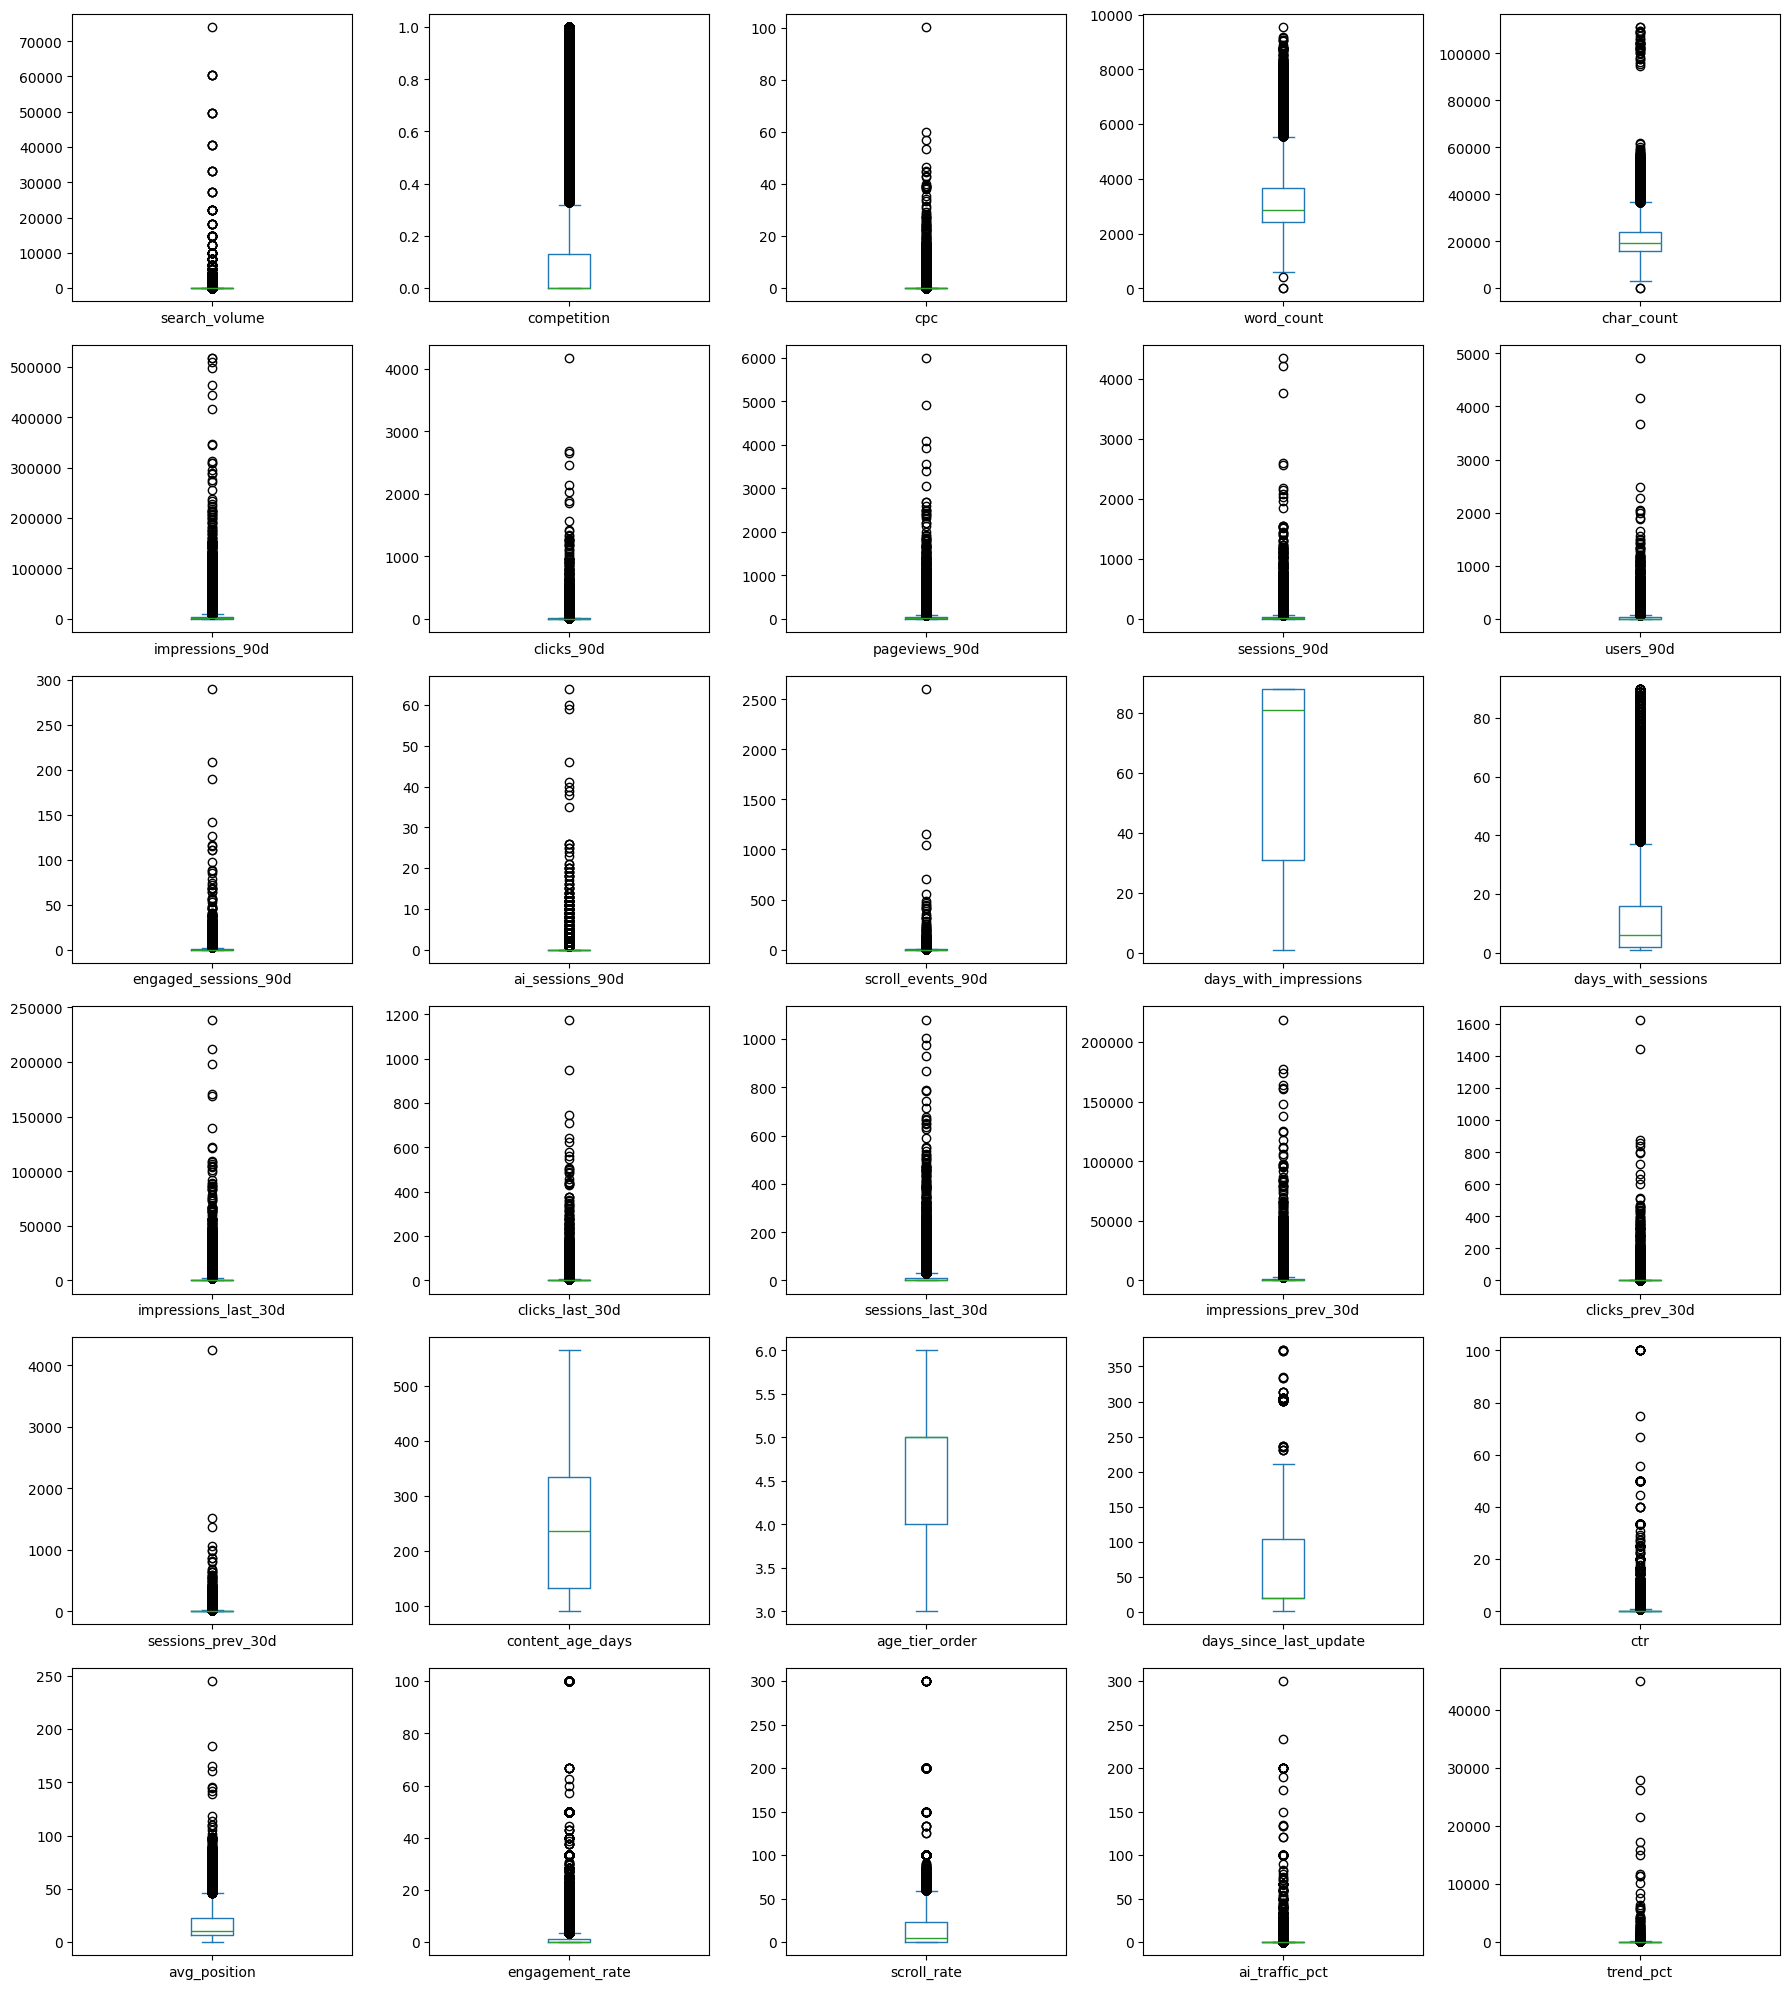

In [22]:
import matplotlib.pyplot as plt

df[numeric_cols].plot(
    kind="box",
    subplots=True,
    layout=(6, 5),
    figsize=(18, 20),
    sharex=False
)

plt.tight_layout()
plt.show()

In [24]:
(
    df[["word_count","char_count","word_count_tier","char_count_tier"]]
    .isna()
    .all(axis=1)
    .value_counts()
)

,count
False,22301
True,7699


In [25]:
missing_groups = (
    df[[
        "word_count",
        "char_count",
        "word_count_tier",
        "char_count_tier"
    ]]
    .isna()
    .astype(int)
)

missing_groups.value_counts()

,,,,count
word_count,char_count,word_count_tier,char_count_tier,
0,0,0,0,22301
1,1,1,1,7699


In [26]:
pd.crosstab(
    df["provider_used"],
    df["model_used"],
    dropna=False
)

model_used,gemini-2.5-flash,gemini-3-flash-preview,gpt-4o-mini,gpt-5-mini,unknown,NaN
provider_used,,,,,,
google,657,6707,0,0,0,0
openai,0,78,456,663,0,1
NaN,3008,6486,4525,935,752,5732


In [27]:
pd.crosstab(
    df["trend_direction"],
    df["trend_pct"].isna()
)

trend_pct,False,True
trend_direction,,
down,16262,0
flat,0,1152
new,0,2236
stable,5962,0
up,4388,0


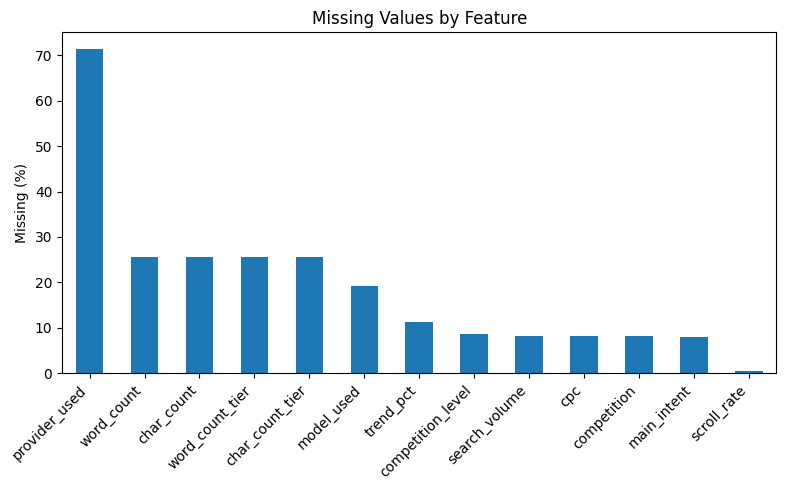

In [28]:
import matplotlib.pyplot as plt

missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(8, 5))
missing_percent.plot(kind="bar")

plt.ylabel("Missing (%)")
plt.title("Missing Values by Feature")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [29]:
# Target variable
y = df["trend_direction"]

# Keep client_id temporarily for grouped splitting
X = df.drop(columns=["trend_direction", "trend_pct", "content_id"])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Feature matrix shape: (30000, 41)
Target shape: (30000,)


,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,...,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier
0,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,...,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking
1,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,...,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5
2,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,...,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5
3,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,...,0-30,NaN,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1
4,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,...,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5


## Feature Selection and Target Definition

Before training the models, the target variable (`trend_direction`) is separated from the feature set.

Several columns are excluded from the predictive features:

- `trend_direction` is the target variable.
- `trend_pct` is removed because it is directly related to the target and would introduce target leakage.
- `content_id` is an identifier unique to each content page and has no predictive value.

The `client_id` column is retained temporarily because it will be used to perform a grouped train/test split. This ensures that pages from the same client do not appear in both the training and testing sets, resulting in a more realistic evaluation.

In [31]:
# Target variable
y = df["trend_direction"]

# Feature matrix
X = df.drop(
    columns=[
        "trend_direction",
        "trend_pct",
        "content_id"
    ]
)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

display(X.head())

Feature matrix shape: (30000, 41)
Target vector shape: (30000,)


,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,...,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier
0,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,...,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking
1,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,...,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5
2,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,...,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5
3,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,...,0-30,NaN,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1
4,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,...,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5


## Grouped Train/Test Split

A grouped train/test split is performed using `client_id`.

Rather than randomly splitting individual rows, all pages belonging to the same client are kept entirely within either the training or testing set.

This prevents information leakage caused by client-specific patterns appearing in both datasets and provides a more realistic estimate of model performance on unseen clients.

In [32]:
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 30

groups = X["client_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25091
Testing samples: 4909


In [33]:
train_clients = set(X_train["client_id"])
test_clients = set(X_test["client_id"])

print("Client overlap:", len(train_clients & test_clients))

Client overlap: 0


In [34]:
X_train = X_train.drop(columns=["client_id"])
X_test = X_test.drop(columns=["client_id"])

print(X_train.shape)
print(X_test.shape)

(25091, 40)
(4909, 40)


## Feature Type Identification

The remaining features contain both numeric and categorical variables.

Numeric and categorical columns are identified automatically based on their data types. This makes the preprocessing pipeline more flexible and avoids manually specifying feature names.

Different preprocessing steps will then be applied to each feature type.

In [35]:
# Separate numeric and categorical features
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

print("\nNumeric columns:")
print(numeric_features)

print("\nCategorical columns:")
print(categorical_features)

Numeric features: 29
Categorical features: 11

Numeric columns:
['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier_order', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']

Categorical columns:
['competition_level', 'content_type', 'main_intent', 'provider_used', 'model_used', 'age_tier', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'impression_tier', 'position_tier']


## Data Preprocessing Pipeline

Missing values are handled separately for numeric and categorical features.

- Numeric features are imputed using the median, which is robust to skewed distributions and outliers.
- Categorical features are imputed using the most frequent category.
- Categorical variables are then converted into numerical representations using one-hot encoding.

These preprocessing steps are implemented within a scikit-learn pipeline. The pipeline is fitted only on the training data and then applied to the test data, preventing data leakage.

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [37]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [38]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
        ),
    ]
)

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['search_volume', 'competition', 'cpc',
                                  'word_count', 'char_count', 'impressions_90d',
                                  'clicks_90d', 'pageviews_90d', 'sessions_90d',
                                  'users_90d', 'engaged_sessions_90d',
                                  'ai_sessions_90d', 'scroll_events_90d',
                                  'days_with_impressions', 'days_with_sessions',
                                  'impr...
                                  'avg_position', 'engagement_rate',
                                  'scroll_rate', 'ai_traffic_pct']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strat

In [40]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (25091, 70)
Processed testing shape: (4909, 70)


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [42]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

## Target Variable and Feature Selection

The prediction target is `trend_direction`, which represents the future content trend.

To prevent data leakage and avoid using non-predictive identifiers:

- `trend_direction` is removed from the feature set because it is the prediction target.
- `trend_pct` is excluded because it is directly used to derive the target.
- `content_id` is excluded because it is a unique identifier with no predictive information.

The `client_id` column is temporarily retained so that the train/test split can be performed at the client level.

In [44]:
# Target
y = df["trend_direction"]

# Features
X = df.drop(
    columns=[
        "trend_direction",
        "trend_pct",
        "content_id"
    ]
)

print("Feature matrix:", X.shape)
print("Target vector :", y.shape)

Feature matrix: (30000, 41)
Target vector : (30000,)


## Grouped Train/Test Split

Instead of randomly splitting rows, the dataset is split by `client_id`.

This ensures that all pages belonging to the same client remain entirely within either the training or testing set. Grouped splitting prevents client-specific information from leaking into the test set and provides a more realistic estimate of model performance on unseen clients.

In [45]:
RANDOM_STATE = 30

groups = X["client_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 25091
Testing samples : 4909


In [46]:
train_clients = set(X_train["client_id"])
test_clients = set(X_test["client_id"])

print("Client overlap:", len(train_clients & test_clients))

Client overlap: 0


In [47]:
X_train.drop(columns="client_id", inplace=True)
X_test.drop(columns="client_id", inplace=True)

In [48]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 29
Categorical features: 11


In [49]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [50]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
        ),
    ]
)

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [52]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (25091, 70)
Processed testing shape : (4909, 70)


In [53]:
import numpy as np

if hasattr(X_train_processed, "toarray"):
    processed = X_train_processed.toarray()
else:
    processed = X_train_processed

print("Missing values after preprocessing:", np.isnan(processed).sum())

Missing values after preprocessing: 0


In [54]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

import matplotlib.pyplot as plt
import pandas as pd

## Logistic Regression

Logistic Regression is used as the baseline classifier.

It models the relationship between the input features and the target classes using a linear decision boundary. Although simple, it provides a useful benchmark for comparing more complex models.

In [55]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            ),
        ),
    ]
)

logistic_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['search_volume',
                                                   'competition', 'cpc',
                                                   'word_count', 'char_count',
                                                   'impressions_90d',
                                                   'clicks_90d',
                                                   'pageviews_90d',
                                                   'sessions_90d', 'users_90d',
                                                   'engaged_sessions_90d',
                                                   'ai_sessions_90d',
                                                   'scroll_events_90d',
                                                   'days_with_impress...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['competition_level',
                                                   'content_type',
                                                   'main_intent',
                                                   'provider_used',
                                                   'model_used', 'age_tier',
                                                   'freshness_tier',
                                                   'word_count_tier',
                                                   'char_count_tier',
                                                   'impression_tier',
                                                   'position_tier'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=30))])

In [56]:
y_pred_lr = logistic_pipeline.predict(X_test)

In [57]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
macro_f1_lr = f1_score(y_test, y_pred_lr, average="macro")

print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Macro F1 : {macro_f1_lr:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.7511
Macro F1 : 0.6189

Classification Report

              precision    recall  f1-score   support

        down       0.92      0.93      0.93      2444
        flat       0.16      0.43      0.23       198
         new       0.42      0.53      0.47       660
      stable       0.93      0.61      0.74       768
          up       0.93      0.62      0.74       839

    accuracy                           0.75      4909
   macro avg       0.67      0.62      0.62      4909
weighted avg       0.82      0.75      0.77      4909



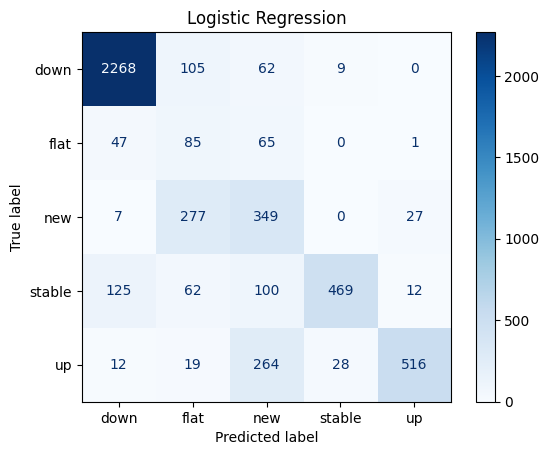

In [58]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Logistic Regression")
plt.show()

In [59]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_lr],
    "Macro F1": [macro_f1_lr]
})

results

,Model,Accuracy,Macro F1
0,Logistic Regression,0.751069,0.618882


Accuracy : 0.9509
Macro F1 : 0.9494
              precision    recall  f1-score   support

        down       0.97      0.98      0.97      2444
        flat       1.00      1.00      1.00       198
         new       1.00      1.00      1.00       660
      stable       0.87      0.83      0.85       768
          up       0.92      0.93      0.93       839

    accuracy                           0.95      4909
   macro avg       0.95      0.95      0.95      4909
weighted avg       0.95      0.95      0.95      4909



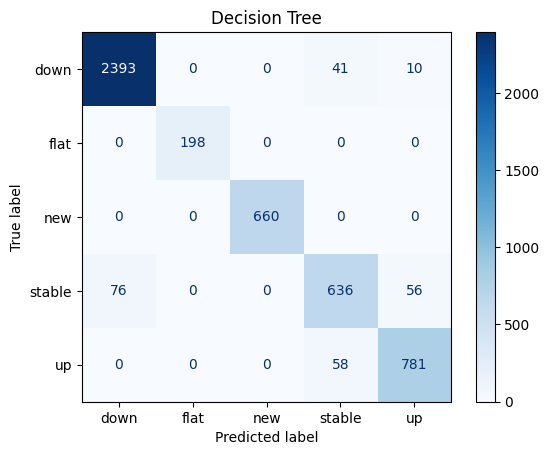

In [60]:
tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            ),
        ),
    ]
)

tree_pipeline.fit(X_train, y_train)

y_pred_tree = tree_pipeline.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
macro_f1_tree = f1_score(y_test, y_pred_tree, average="macro")

print(f"Accuracy : {accuracy_tree:.4f}")
print(f"Macro F1 : {macro_f1_tree:.4f}")

print(classification_report(y_test, y_pred_tree))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    cmap="Blues"
)

plt.title("Decision Tree")
plt.show()

results.loc[len(results)] = [
    "Decision Tree",
    accuracy_tree,
    macro_f1_tree
]

Accuracy : 0.7472
Macro F1 : 0.7050
              precision    recall  f1-score   support

        down       0.68      0.99      0.80      2444
        flat       1.00      1.00      1.00       198
         new       1.00      1.00      1.00       660
      stable       0.66      0.12      0.21       768
          up       0.88      0.36      0.51       839

    accuracy                           0.75      4909
   macro avg       0.84      0.69      0.70      4909
weighted avg       0.77      0.75      0.69      4909



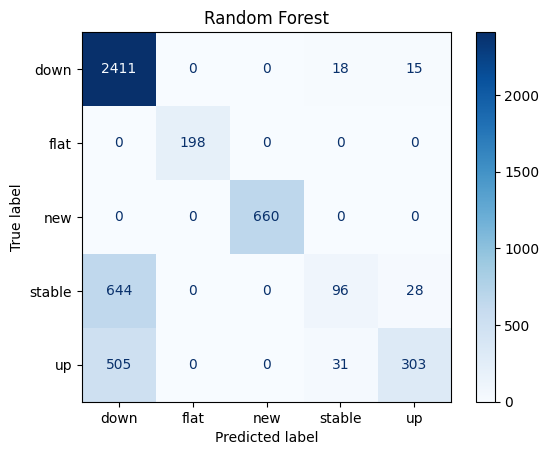

In [61]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE
            ),
        ),
    ]
)

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
macro_f1_rf = f1_score(y_test, y_pred_rf, average="macro")

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Macro F1 : {macro_f1_rf:.4f}")

print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Random Forest")
plt.show()

results.loc[len(results)] = [
    "Random Forest",
    accuracy_rf,
    macro_f1_rf
]

In [62]:
results.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Macro F1
0,Decision Tree,0.950906,0.949382
1,Random Forest,0.747199,0.704964
2,Logistic Regression,0.751069,0.618882


In [63]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importances = tree_pipeline.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
15,num__impressions_last_30d,0.462836
18,num__impressions_prev_30d,0.449599
21,num__content_age_days,0.031582
25,num__avg_position,0.016657
5,num__impressions_90d,0.003992
3,num__word_count,0.002672
0,num__search_volume,0.002319
16,num__clicks_last_30d,0.002139
26,num__engagement_rate,0.001878
27,num__scroll_rate,0.001857


In [64]:
df["trend_direction"].value_counts()

,count
trend_direction,
down,16262
stable,5962
up,4388
new,2236
flat,1152


In [65]:
df["trend_direction"].value_counts(normalize=True) * 100

,proportion
trend_direction,
down,54.206667
stable,19.873333
up,14.626667
new,7.453333
flat,3.840000


In [68]:
df[
    [
        "impressions_prev_30d",
        "impressions_last_30d",
        "trend_pct",
        "trend_direction"
    ]
].sample(20, random_state=30)

,impressions_prev_30d,impressions_last_30d,trend_pct,trend_direction
7707,1459,326,-77.7,down
17433,1386,1547,11.6,stable
15668,0,1,NaN,new
21926,72,50,-30.6,down
28353,0,0,NaN,flat
15206,1493,1763,18.1,stable
24553,2,1,-50.0,down
8663,252,84,-66.7,down
20946,223,99,-55.6,down
28463,2,0,-100.0,down


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

In [18]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
best_pipeline = trained_models["Decision Tree"]

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.